<a href="https://colab.research.google.com/github/VarvaraSharutina/bioinfo/blob/main/bioinf_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Математические методы биоинформатики

### Home work 2. Проверка статистических гипотез

### Задание.

В файле *immunology_dataset.csv* представлены иммунологические данные для трех групп людей (переменная Group):

- Здоровые (Healthy)  
- Пациенты с аутоиммунным заболеванием (Autoimmune)  
- Пациенты с  онкологическим заболеванием (Cancer)  

Для каждого пациента измерены следующие показатели:  
- Пол (Gender) — категориальная переменная (M/F)  
- Возраст (Age) — количественная переменная (годы)  
- Индекс массы тела (BMI) — количественная переменная  
- Уровень экспрессии гена IL6 (IL6_expression) — количественная переменная  
- Уровень экспрессии гена TNFα (TNF_expression) — количественная переменная  
- Уровень С-реактивного белка (CRP) — количественная переменная (мг/л)  
- Количество лейкоцитов (WBC) — количественная переменная (тыс/мкл)  
- Наличие аутоантител (Autoantibodies) — бинарная переменная  

Ответьте на следующие вопросы и выполните задания на основе представленного датасета:

1) Проверьте все количественные переменные на нормальность. Постройте для каждой рассматриваемой переменной PDF (на одном рисунке).

2) Постройте диаграммы рассеяния между переменными IL6 и TNFα, а также между переменными BMI и Age. На каждой из них раскрасьте точки разными цветами в зависимости от группы. Наблюдается ли взаимосвязь в парах указанных переменных (пока просто предположите на основе графиков)?

3) Постройте тепловую карту матрицы корреляций для всех количественных переменных. Выпишите пары переменных, для которых наблюдается положительная корреляция или отрицательная корреляция.

4) Наблюдается ли статистически значимая корреляция между уровнями экспрессии IL6 и TNFα в общем случае (рассмотреть всех людей)? Различается ли эта корреляция по группам?

5) Отличается ли уровень экспрессии IL6 между здоровыми и онкологическими пациентами?

6) Отличается ли возраст между тремя группами?

7) Наблюдается ли более высокий уровень CRP в группе аутоимунных заболеваний по сравнению со здоровой группой?

8) Наблюдается ли связь между группой и наличием аутоантител?

9) Наблюдается ли связь между полом и наличием аутоантител в группе аутоимунных заболеваний?

10) Какие из переменных (Age, BMI, IL6_expression, TNF_expression, CRP и WBC) статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest

url = "https://raw.githubusercontent.com/VarvaraSharutina/bioinfo/main/immunology_dataset.csv"
data_raw = pd.read_csv(url)

In [3]:
data_raw

,Group,Gender,Age,BMI,IL6_expression,TNF_expression,CRP,WBC,Autoantibodies
0,Cancer,M,52,24.3,14.55,2.30,4.7,10.4,1
1,Autoimmune,F,21,22.6,10.75,18.85,20.1,8.1,1
2,Healthy,F,42,24.8,2.24,3.12,0.2,6.6,0
3,Cancer,M,60,21.8,8.15,7.04,4.3,13.4,0
4,Cancer,F,49,28.4,13.86,3.78,0.1,5.5,0
...,...,...,...,...,...,...,...,...,...
95,Healthy,M,57,21.0,6.62,2.05,0.4,8.6,0
96,Autoimmune,M,58,27.3,4.71,10.96,3.8,9.0,1
97,Cancer,F,65,26.1,3.79,8.78,0.4,16.3,0
98,Cancer,F,65,24.1,16.12,5.51,1.5,11.3,0


1. Проверим все количественные переменные на нормальность. Построим для каждой рассматриваемой переменной PDF (на одном рисунке).


Age:
Значение статистики: 0.9884007667050628
p-value: 0.5382105731948345
Набор данных распределен нормально

BMI:
Значение статистики: 0.9946530333810354
p-value: 0.9651500142921079
Набор данных распределен нормально

IL6_expression:
Значение статистики: 0.9141212774556133
p-value: 6.955900314526998e-06
Набор данных не распределен нормально

TNF_expression:
Значение статистики: 0.9165993712690429
p-value: 9.332324098124695e-06
Набор данных не распределен нормально

CRP:
Значение статистики: 0.6452492988443829
p-value: 3.392531721929531e-14
Набор данных не распределен нормально

WBC:
Значение статистики: 0.9816540024672402
p-value: 0.1784897132054304
Набор данных распределен нормально


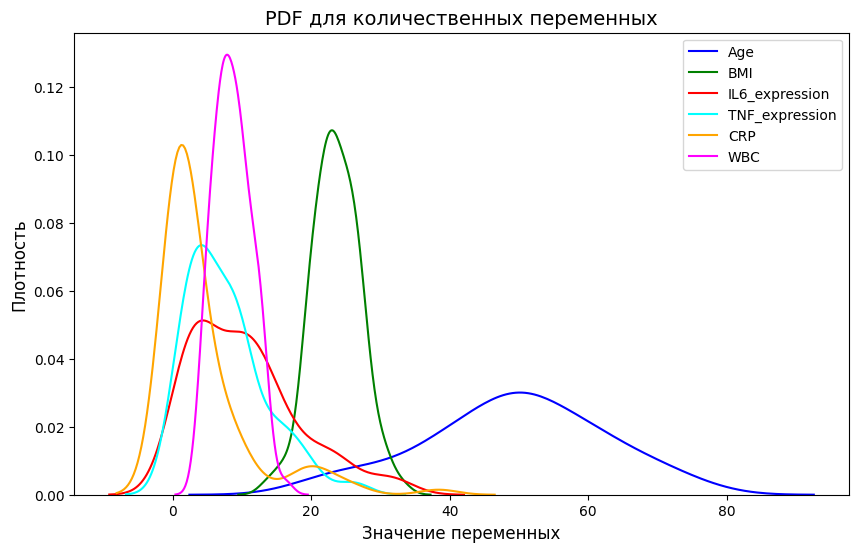

In [4]:
columns = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
colors = ['blue', 'green', 'red', 'cyan', 'orange', 'magenta']

plt.figure(figsize=(10, 6))

for i, var in enumerate(columns):
  data = data_raw[var]
  statistic, pvalue = stats.shapiro(data)

  print(f"\n{var}:")
  print(f"Значение статистики: {statistic}") # Значение статистики W измеряет отклонение набора данных от нормального распределения
  print(f"p-value: {pvalue}") # p-значение указывает на вероятность того, что набор данных распределён нормально. Если p-значение меньше 0,05, это suggests, что набор данных не распределён нормально.
  if (pvalue<0.05):
    print(f"Набор данных не распределен нормально")
  else:
    print(f"Набор данных распределен нормально")

  sns.kdeplot(data, label=var, color=colors[i])

plt.title('PDF для количественных переменных', fontsize=14)
plt.xlabel('Значение переменных', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.show()



2. Построим диаграммы рассеяния между переменными IL6 и TNFα, а также между переменными BMI и Age. На каждой из них раскрасим точки разными цветами в зависимости от группы. Наблюдается ли взаимосвязь в парах указанных переменных (пока просто предположите на основе графиков)?

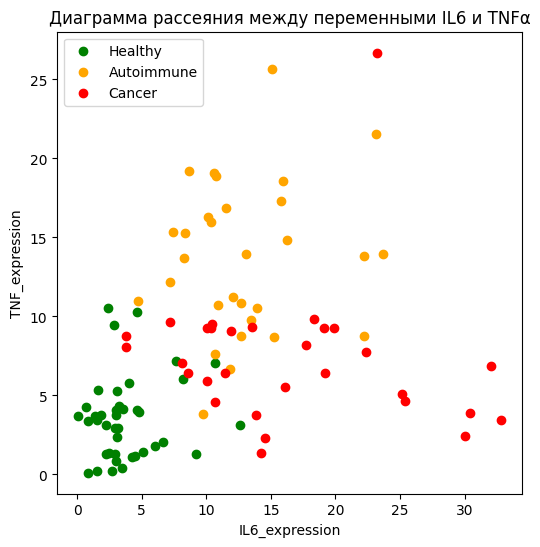

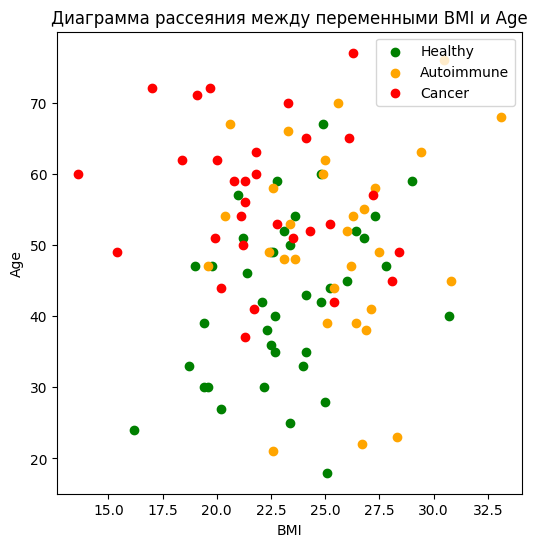

In [5]:
colors_group = {'Healthy': 'green', 'Autoimmune': 'orange', 'Cancer': 'red'}

plt.figure(figsize=(6, 6))
for group, color in colors_group.items():
  group_data = data_raw[data_raw['Group'] == group]
  plt.scatter(group_data['IL6_expression'], group_data['TNF_expression'], c=color, label=group)

plt.title("Диаграмма рассеяния между переменными IL6 и TNFα")
plt.xlabel("IL6_expression")
plt.ylabel("TNF_expression")
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
for group, color in colors_group.items():
  group_data = data_raw[data_raw['Group'] == group]
  plt.scatter(group_data['BMI'], group_data['Age'], c=color, label=group)

plt.title("Диаграмма рассеяния между переменными BMI и Age")
plt.xlabel("BMI")
plt.ylabel("Age")
plt.legend()
plt.show()

По построенным графикам можно сделать вывод, что между переменными BMI и Age какая-либо взаимосвязь отсутвует, а в паре переменных IL6 и TNFα есть намёк на положительную связь, и можно заметить, что маленькие значения уровня экпрессии обоих генов свойствены для здоровых пациентов, высокий уровень экпрессии IL6 - пациентов с онкологическими заболеванием, высокий уровень экпрессии TNFα - пациентов с аутоимунным заболеванием

3. Построим тепловую карту матрицы корреляций для всех количественных переменных. Выпишим пары переменных, для которых наблюдается положительная корреляция или отрицательная корреляция.

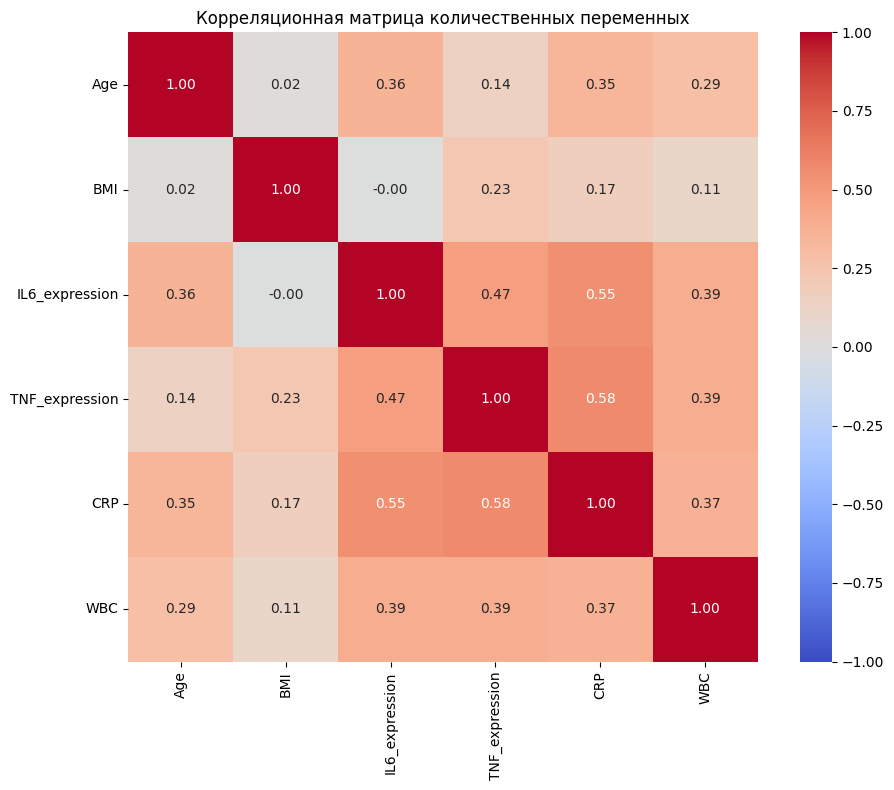

In [6]:
columns = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
data = data_raw[columns]
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True, fmt='.2f', vmin=-1, vmax=1)
plt.title("Корреляционная матрица количественных переменных")
plt.tight_layout()
plt.show()



*   Age и BMI - очень слабая положительная корреляция
*   Age и IL6_expression - слабая положительная корреляция
*   Age и TNF_expression - очень слабая положительная корреляция
*   Age и CRP - слабая положительная корреляция
*   Age и WBC - слабая положительная корреляция
---
*   BMI и IL6_expression - нет корреляции
*   BMI и TNF_expression - слабая положительная корреляция
*   BMI и CRP - очень слабая положительная корреляция
*   BMI и WBC - очень слабая положительная корреляция
---
*   IL6_expression и TNF_expression - слабая положительная корреляция
*   IL6_expression и CRP - средняя положительная корреляция
*   IL6_expression и WBC - слабая положительная корреляция
---
*   TNF_expression и CRP - средняя положительная корреляция
*   TNF_expression и WBC - слабая положительная корреляция
---
*   WBC и CRP - слабая положительная корреляция


4. Наблюдается ли статистически значимая корреляция между уровнями экспрессии IL6 и TNFα в общем случае (рассмотреть всех людей)? Различается ли эта корреляция по группам?

In [7]:
statistic, pvalue = stats.spearmanr(data_raw['IL6_expression'], data_raw['TNF_expression'])
print(f"Коэффициент корреляции Спирмена: {statistic}")
print(f"p-значение: {pvalue}")
print("-" * 60)

data_healthy = data_raw[data_raw['Group'] == 'Healthy']
statistic1, pvalue1 = stats.spearmanr(data_healthy['IL6_expression'], data_healthy['TNF_expression'])
print(f"Коэффициент корреляции Спирмена для группы здоровых пациентов: {statistic1}")
print(f"p-значение для группы здоровых пациентов: {pvalue1}")
print("-" * 60)

data_autoimmune = data_raw[data_raw['Group'] == 'Autoimmune']
statistic2, pvalue2 = stats.spearmanr(data_autoimmune['IL6_expression'], data_autoimmune['TNF_expression'])
print(f"Коэффициент корреляции Спирмена для группы пациентов с аутоимунным заболеванием: {statistic2}")
print(f"p-значение для группы пациентов с аутоимунным заболеванием: {pvalue2}")
print("-" * 60)

data_cancer = data_raw[data_raw['Group'] == 'Cancer']
statistic2, pvalue2 = stats.spearmanr(data_cancer['IL6_expression'], data_cancer['TNF_expression'])
print(f"Коэффициент корреляции Спирмена для группы пациентов с онкологическим заболеванием: {statistic2}")
print(f"p-значение для группы пациентов с онкологическим заболеванием: {pvalue2}")



Коэффициент корреляции Спирмена: 0.4699772275368377
p-значение: 8.08378272009708e-07
------------------------------------------------------------
Коэффициент корреляции Спирмена для группы здоровых пациентов: 0.13725490256482328
p-значение для группы здоровых пациентов: 0.3983581586845464
------------------------------------------------------------
Коэффициент корреляции Спирмена для группы пациентов с аутоимунным заболеванием: 0.03670745272525028
p-значение для группы пациентов с аутоимунным заболеванием: 0.8472906542071432
------------------------------------------------------------
Коэффициент корреляции Спирмена для группы пациентов с онкологическим заболеванием: -0.3059294712445078
p-значение для группы пациентов с онкологическим заболеванием: 0.10014820032592178


Наблюдается статистически слабая положительная корреляция между уровнями экспрессии IL6 и TNFα в общем случае.

Корреляция по группам отличается - во всех трёх случаях она уменьшилась по сравнению с общим случаем. У группы пациентов с онкологическим заболеванием она стала отрицательной и меньшей по модулю, а у группы с аутоимунным заболеванием стала очень слабой, но осталось положительной, у здоровых пациентов она также уменьшилась.

5. Отличается ли уровень экспрессии IL6 между здоровыми и онкологическими пациентами?

In [8]:
# Проверим выборки на нормальность
statistic_h, pvalue_h = stats.shapiro(data_healthy['IL6_expression'])
print(f"Healthy:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

statistic_h, pvalue_h = stats.shapiro(data_cancer['IL6_expression'])
print(f"\nCancer:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

# Если p < 0,05, различия между группами статистически значимы, если p ≥ 0,05 — различий нет
u_stat, pv_mw = stats.mannwhitneyu(data_healthy['IL6_expression'], data_cancer['IL6_expression'], alternative='two-sided')
print(f"\nКритерий Манна-Уитни:")
print(f"Значение статистики: {u_stat}") # мера различия рангов
print(f"p-value: {pv_mw}")

Healthy:
Значение статистики: 0.8636009941815733
p-value: 0.00019584480921351475
Набор данных не распределен нормально

Cancer:
Значение статистики: 0.9453097590051946
p-value: 0.12646084098090615
Набор данных распределен нормально

Критерий Манна-Уитни:
Значение статистики: 52.0
p-value: 8.159540554362873e-11


Уровень экспрессии IL6 статичеки значимо различается между здоровой группой пациентов и пациентов с онкологическим заболеванием.

6. Отличается ли возраст между тремя группами?

In [23]:
# Проверим выборки на нормальность
statistic_h, pvalue_h = stats.shapiro(data_healthy['Age'])
print(f"Healthy:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

statistic_h, pvalue_h = stats.shapiro(data_autoimmune['Age'])
print(f"\nCancer:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

statistic_h, pvalue_h = stats.shapiro(data_cancer['Age'])
print(f"\nCancer:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

# Проверим равенство дисперсий
stat_bartlett, pv_bartlett = stats.bartlett(data_healthy['Age'], data_autoimmune['Age'], data_cancer['Age'])
print("\nКритерий Бартлетта:")
print("Статистика:", stat_bartlett)
print("p-value:", pv_bartlett)
if pv_bartlett < 0.05:
    print("Дисперсии статистически различаются")
else:
    print("Нет оснований считать дисперсии различными")

stat_anova, pv_anova = stats.f_oneway(data_healthy['Age'], data_autoimmune['Age'], data_cancer['Age'])
print(f"\nКритерий Anova:")
print(f"Значение статистики: {stat_anova}")
print(f"p-value: {pv_anova}")

Healthy:
Значение статистики: 0.9878494049911483
p-value: 0.9386257266748825
Набор данных распределен нормально

Cancer:
Значение статистики: 0.9614835115594147
p-value: 0.3378480027876258
Набор данных распределен нормально

Cancer:
Значение статистики: 0.9832373161129996
p-value: 0.9035165493526306
Набор данных распределен нормально

Критерий Бартлетта:
Статистика: 4.266958301456346
p-value: 0.11842455939399292
Нет оснований считать дисперсии различными

Критерий Anova:
Значение статистики: 12.379555685073347
p-value: 1.627825414019538e-05


Различия возраста между тремя группами статистически значимы.

7. Наблюдается ли более высокий уровень CRP в группе аутоимунных заболеваний по сравнению со здоровой группой?

In [10]:
# Проверим выборки на нормальность
statistic_h, pvalue_h = stats.shapiro(data_healthy['CRP'])
print(f"Healthy:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

statistic_h, pvalue_h = stats.shapiro(data_autoimmune['CRP'])
print(f"\nCancer:")
print(f"Значение статистики: {statistic_h}")
print(f"p-value: {pvalue_h}")
if (pvalue_h<0.05):
  print(f"Набор данных не распределен нормально")
else:
  print(f"Набор данных распределен нормально")

u_stat, pv_mw = stats.mannwhitneyu(data_autoimmune['CRP'], data_healthy['CRP'], alternative='greater' )
print(f"\nКритерий Манна-Уитни:")
print(f"Значение статистики: {u_stat}")
print(f"p-value: {pv_mw}")

Healthy:
Значение статистики: 0.9015993820948416
p-value: 0.0021286228247183827
Набор данных не распределен нормально

Cancer:
Значение статистики: 0.8142331477602579
p-value: 0.00012047266117213537
Набор данных не распределен нормально

Критерий Манна-Уитни:
Значение статистики: 1069.0
p-value: 1.3115611464127397e-08


Так как p-value$<0.05$ CRP выше в группе аутоимунных заболеваний.



8. Наблюдается ли связь между группой и наличием аутоантител?

In [11]:
contingency_table = pd.crosstab(data_raw["Group"], data_raw["Autoantibodies"]) # таблица сопряженности
print(contingency_table)

chi2, pv, dof, expected = stats.chi2_contingency(contingency_table)
print("\nКритерий однородности хи-квадрат Пирсона:")
print("\nСтатистика хи-квадрат:", chi2)
print("p-value:", pv)
print("Число стопеней свободы:", dof)
print("Ожидаемые частоты:")
print(expected)

Autoantibodies   0   1
Group                 
Autoimmune       7  23
Cancer          23   7
Healthy         33   7

Критерий независимости хи-квадрат Пирсона:

Статистика хи-квадрат: 29.17917917917918
p-value: 4.6112827005185607e-07
Число стопеней свободы: 2
Ожидаемые частоты:
[[18.9 11.1]
 [18.9 11.1]
 [25.2 14.8]]


Так как p-value$<0.05$, то связь между группой и наличием аутоантител есть, то есть их наличие зависит от группы.

9. Наблюдается ли связь между полом и наличием аутоантител в группе аутоимунных заболеваний?

In [12]:
contingency_table = pd.crosstab(data_autoimmune["Gender"], data_autoimmune["Autoantibodies"]) # таблица сопряженности
print(contingency_table)

chi2, pv, dof, expected = stats.chi2_contingency(contingency_table)
print("\nКритерий независимости хи-квадрат Пирсона:")
print("\nСтатистика хи-квадрат:", chi2)
print("p-value:", pv)
print("Число стопеней свободы:", dof)
print("Ожидаемые частоты:")
print(expected)

Autoantibodies  0   1
Gender               
F               7  15
M               0   8

Критерий независимости хи-квадрат Пирсона:

Статистика хи-квадрат: 1.779714850367024
p-value: 0.18218434506724362
Число стопеней свободы: 1
Ожидаемые частоты:
[[ 5.13333333 16.86666667]
 [ 1.86666667  6.13333333]]


Так как p-value$>0.05$, то связь между полом и наличием аутоантител нет (возможно для более верных выводов стоит увеличить выборку)

10. Какие из переменных (Age, BMI, IL6_expression, TNF_expression, CRP и WBC) статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой?

In [13]:
columns = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
for var in columns:
  u_stat, pv_mw = stats.mannwhitneyu(data_autoimmune[var], data_cancer[var], alternative='two-sided')
  print(f"\nКритерий Манна-Уитни для", var)
  print(f"Значение статистики: {u_stat}")
  print(f"p-value: {pv_mw}")


Критерий Манна-Уитни для Age
Значение статистики: 332.0
p-value: 0.08218682560959994

Критерий Манна-Уитни для BMI
Значение статистики: 692.5
p-value: 0.00034586495138787244

Критерий Манна-Уитни для IL6_expression
Значение статистики: 348.0
p-value: 0.13345408758779304

Критерий Манна-Уитни для TNF_expression
Значение статистики: 787.0
p-value: 6.523811813545671e-07

Критерий Манна-Уитни для CRP
Значение статистики: 547.0
p-value: 0.1535471902640417

Критерий Манна-Уитни для WBC
Значение статистики: 442.0
p-value: 0.9116820881479285


Коррекция Бонферрони: $p^*=\frac{\alpha}{m}$, где $m=6$ (количество сравнений)

$p^*=0.0083$

Смотрим значение p-value:
* если  p-value$<0.0083$, то переменные статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой
* если p-value$≥0.0083$, то то переменные статистически значимо **не** отличаются между группой аутоимунных заболеваний и онкологической группой

Получаем, что значимо отличаются BMI и TNF_expression